# Início - Projeto Final - PGC201 Mineração de Dados (PPGCO/UFU)

# Bank Marketing - Agrupamento

> **Objetivo**: identificar segmentos naturais de clientes usando algoritmos de agrupamento não-supervisionado

> **Dataset:** [Bank Marketing - UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

> **Referência:** [Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22-31.](https://doi.org/10.1016/j.dss.2014.03.001)

> **Versão:** `bank-additional-full.csv` (41.188 instâncias, 20 features + target)

---

# Configurações

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

In [2]:
# import warnings
# warnings.filterwarnings("ignore")

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import json, joblib

In [5]:
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [6]:
# --- redução de dimenisonalidade ---
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [7]:
# --- agrupadores ---
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors

In [8]:
# --- avaliação ---
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score
)

In [9]:
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [10]:
SEED = 42

42

---

# Roadmap

| Etapa | Descrição |
|---|---|
| 1 | Preparação: seleção de features, PCA para redução de dimensionalidade |
| 2 | Determinação do número de clusters (Elbow + Silhouette) |
| 3 | K-Means |
| 4 | DBSCAN |
| 5 | Agrupamento Hierárquico (Agglomerative) + dendrograma |
| 6 | Gaussian Mixture Model (GMM) - abordagem probabilística |
| 7 | Comparação, perfilamento dos clusters e conclusão |

---

# Carregando Artefatos

In [11]:
X_train = pd.read_csv("artifacts/X_train_enc.csv", index_col=0)
y_train = pd.read_csv("artifacts/y_train.csv", index_col=0).squeeze()

with open("artifacts/metadata.json") as f:
    meta = json.load(f)

---

# Preparação

> Em Agrupamento, utilizamos o treino completo (sem target)

> PCA reduz dimensionalidade e resolve multicolinearidade (presente no bloco socioeconômico)

## _Principal Component Analysis_ (PCA)

In [12]:
pca = PCA(n_components=0.95, random_state=SEED)  # tentar reter 95% da variância
X_pca = pca.fit_transform(X_train)

n_comp = pca.n_components_
var_explained = pca.explained_variance_ratio_.sum();

In [13]:
print(f"Features originais: {X_train.shape[1]}")
print(f"Componentes PCA (95% variância): {n_comp}")
print(f"Variância retida: {var_explained * 100:.2f}%")

Features originais: 53
Componentes PCA (95% variância): 24
Variância retida: 95.20%


> O número de features ter subido de 20 pra 53 é por conta de `OneHotEncoder` feito na análise inicial

A Análise de Componentes Principais projeta os dados num espaço de menor dimensão, \
tentando preservar a máxima variância possível ao longo de eixos perpendiculares.

Procedimento:
1. Centralizar os dados: $X_c = X - \bar{X}$
2. Calcular a matriz de covariância: $\Sigma = \frac{1}{n} X_c^T X_c$
3. Obter autovalores e autovetores: $\Sigma w_i = \lambda_i w_i$
4. Projetar nos $k$ autovetores de maior autovalor: $X_{\text{pca}} = X_c \cdot W$

Cada componente captura variância proporcional ao seu autovalor: 

$$\text{var\_explicada}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

> Com 95% de variância retida, reduzimos de 53 para 24 componentes

---

# Determinação do Número de Clusters

## Dois métodos para escolher $k$

**Elbow (cotovelo):** plota a inércia (soma das distâncias quadráticas \
de cada ponto ao centroide do seu cluster) em função de $k$. Assim, \
procura-se o "cotovelo" onde o ganho marginal diminui.

$$\text{Inércia} = \sum_{k} \sum_{x \in C_k} \|x - \mu_k\|^2$$

**Silhouette (silhueta):** mede quão similar cada ponto é ao seu\
cluster comparado ao vizinho mais próximo. Para cada ponto $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\; b(i))}$$

onde $a(i)$ = distância média aos pontos do mesmo cluster e\
$b(i)$ = distância média ao cluster vizinho mais próximo.

Temos que $s \in [-1, 1]$: valores altos indicam atribuição correta,\
negativos indicam que o ponto "deveria" estar em outro cluster.

| Silhouette médio | Interpretação |
|---|---|
| $> 0.50$ | Estrutura forte |
| $0.25 - 0.50$ | Estrutura razoável |
| $< 0.25$ | Estrutura fraca ou ausente |

---

# K-means

O algoritmo mais clássico de agrupamento. Procedimento iterativo:

1. Inicializar $k$ centroides (aleatoriamente ou via k-means++)
2. **Atribuir** cada ponto ao centroide mais próximo
3. **Atualizar** cada centroide como a média dos pontos atribuídos
4. Repetir passos 2 e 3 até convergência (centroides param de se mover)

O K-Means minimiza a inércia. Assume clusters esféricos e de \
tamanho similar - limitação que os outros algoritmos relaxam.

O $k$ escolhido é baseado de acordo com os gráficos: o cotovelo \
na curva de inércia e/ou o pico na curva de silhouette.

## Execução em diferentes valores de $k$

In [14]:
K_range = range(2, 11)
inertias = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

    labels_sample = km.predict(X_pca)
    sil = silhouette_score(X_pca, labels_sample)
    sil_scores.append(sil)
    print(f"k={k:>2} | Inércia: {km.inertia_:>12.1f} | Silhouette: {sil:.4f}")

k= 2 | Inércia:     260407.4 | Silhouette: 0.3074
k= 3 | Inércia:     239661.7 | Silhouette: 0.2833
k= 4 | Inércia:     225406.3 | Silhouette: 0.1490
k= 5 | Inércia:     210522.9 | Silhouette: 0.1540
k= 6 | Inércia:     199262.2 | Silhouette: 0.1437
k= 7 | Inércia:     187779.5 | Silhouette: 0.1749
k= 8 | Inércia:     177388.8 | Silhouette: 0.1642
k= 9 | Inércia:     169776.2 | Silhouette: 0.1690
k=10 | Inércia:     163718.9 | Silhouette: 0.1818


## Visualização da Escolha de $k$

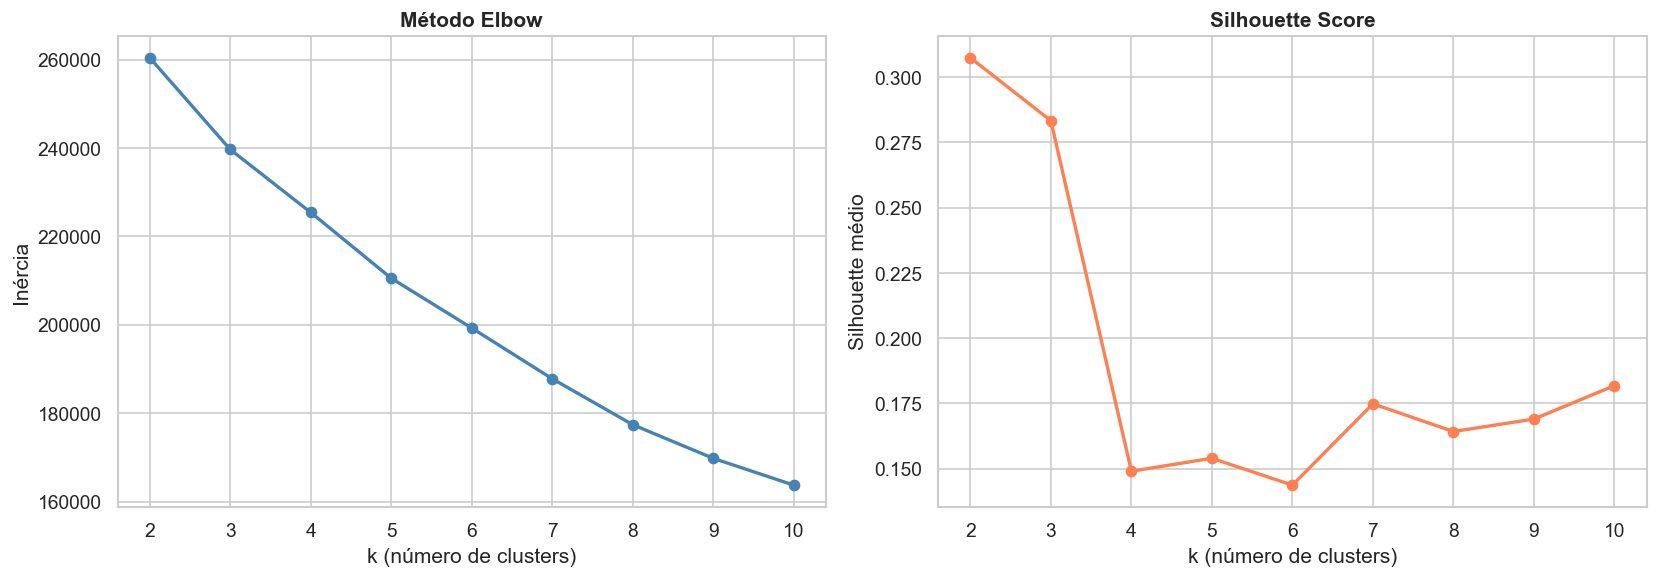

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("k (número de clusters)")
axes[0].set_ylabel("Inércia")
axes[0].set_title("Método Elbow", fontweight="bold")
axes[0].set_xticks(list(K_range))

axes[1].plot(K_range, sil_scores, "o-", color="coral", linewidth=2)
axes[1].set_xlabel("k (número de clusters)")
axes[1].set_ylabel("Silhouette médio")
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xticks(list(K_range))

plt.tight_layout()
fig.savefig("figures/agrup_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

> Pelos gráficos, o melhor $k$ parece ser 2 ou 3

## K = 2

In [20]:
K_BEST = 2

km_final = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=20)
km_labels = km_final.fit_predict(X_pca)

sil_km = silhouette_score(X_pca, km_final.predict(X_pca))
ch_km  = calinski_harabasz_score(X_pca, km_labels)
db_km  = davies_bouldin_score(X_pca, km_labels)

print(f"K-Means (k={K_BEST})")
print(f"  Silhouette:        {sil_km:.4f}")
print(f"  Calinski-Harabasz: {ch_km:.1f}  (maior = melhor)")
print(f"  Davies-Bouldin:    {db_km:.4f}   (menor = melhor)")
print(f"\nDistribuição dos clusters:")
print(pd.Series(km_labels).value_counts().sort_index())

K-Means (k=2)
  Silhouette:        0.3074
  Calinski-Harabasz: 11310.3  (maior = melhor)
  Davies-Bouldin:    1.4651   (menor = melhor)

Distribuição dos clusters:
0    19351
1     9478
Name: count, dtype: int64


## K = 3

In [21]:
K_BEST = 3

km_final = KMeans(n_clusters=K_BEST, random_state=SEED, n_init=20)
km_labels = km_final.fit_predict(X_pca)

sil_km = silhouette_score(X_pca, km_final.predict(X_pca))
ch_km  = calinski_harabasz_score(X_pca, km_labels)
db_km  = davies_bouldin_score(X_pca, km_labels)

print(f"K-Means (k={K_BEST})")
print(f"  Silhouette:        {sil_km:.4f}")
print(f"  Calinski-Harabasz: {ch_km:.1f}  (maior = melhor)")
print(f"  Davies-Bouldin:    {db_km:.4f}  (menor = melhor)")
print(f"\nDistribuição dos clusters:")
print(pd.Series(km_labels).value_counts().sort_index())

K-Means (k=3)
  Silhouette:        0.2833
  Calinski-Harabasz: 7392.1  (maior = melhor)
  Davies-Bouldin:    1.7024  (menor = melhor)

Distribuição dos clusters:
0     6792
1    19349
2     2688
Name: count, dtype: int64


## Métricas de Avaliação

**Calinski-Harabasz (CH)** - *Variance Ratio Criterion:*\
razão entre a dispersão *entre* clusters e *dentro* dos clusters

$$\text{CH} = \frac{\text{tr}(B_k)\,/\,(k-1)}{\text{tr}(W_k)\,/\,(n-k)}$$

onde $B_k$ é a matriz de dispersão entre clusters e $W_k$ a de dentro.

**Maior = melhor** $\rightarrow$ Favorece clusters compactos e bem separados.

**Davies-Bouldin (DB):** pra cada cluster, vê \
a similaridade com o cluster mais parecido

$$\text{DB} = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i}
\frac{s_i + s_j}{d_{ij}}$$

onde $s_i$ = distância média dos pontos ao centroide $i$ e\
$d_{ij}$ = distância entre centroides.

**Menor = melhor** $\rightarrow$ ($\text{DB} = 0$ seria perfeito) \
Penaliza clusters espalhados ($s$ alto) e próximos entre si ($d$ baixo).

## Visualização dos Clusters

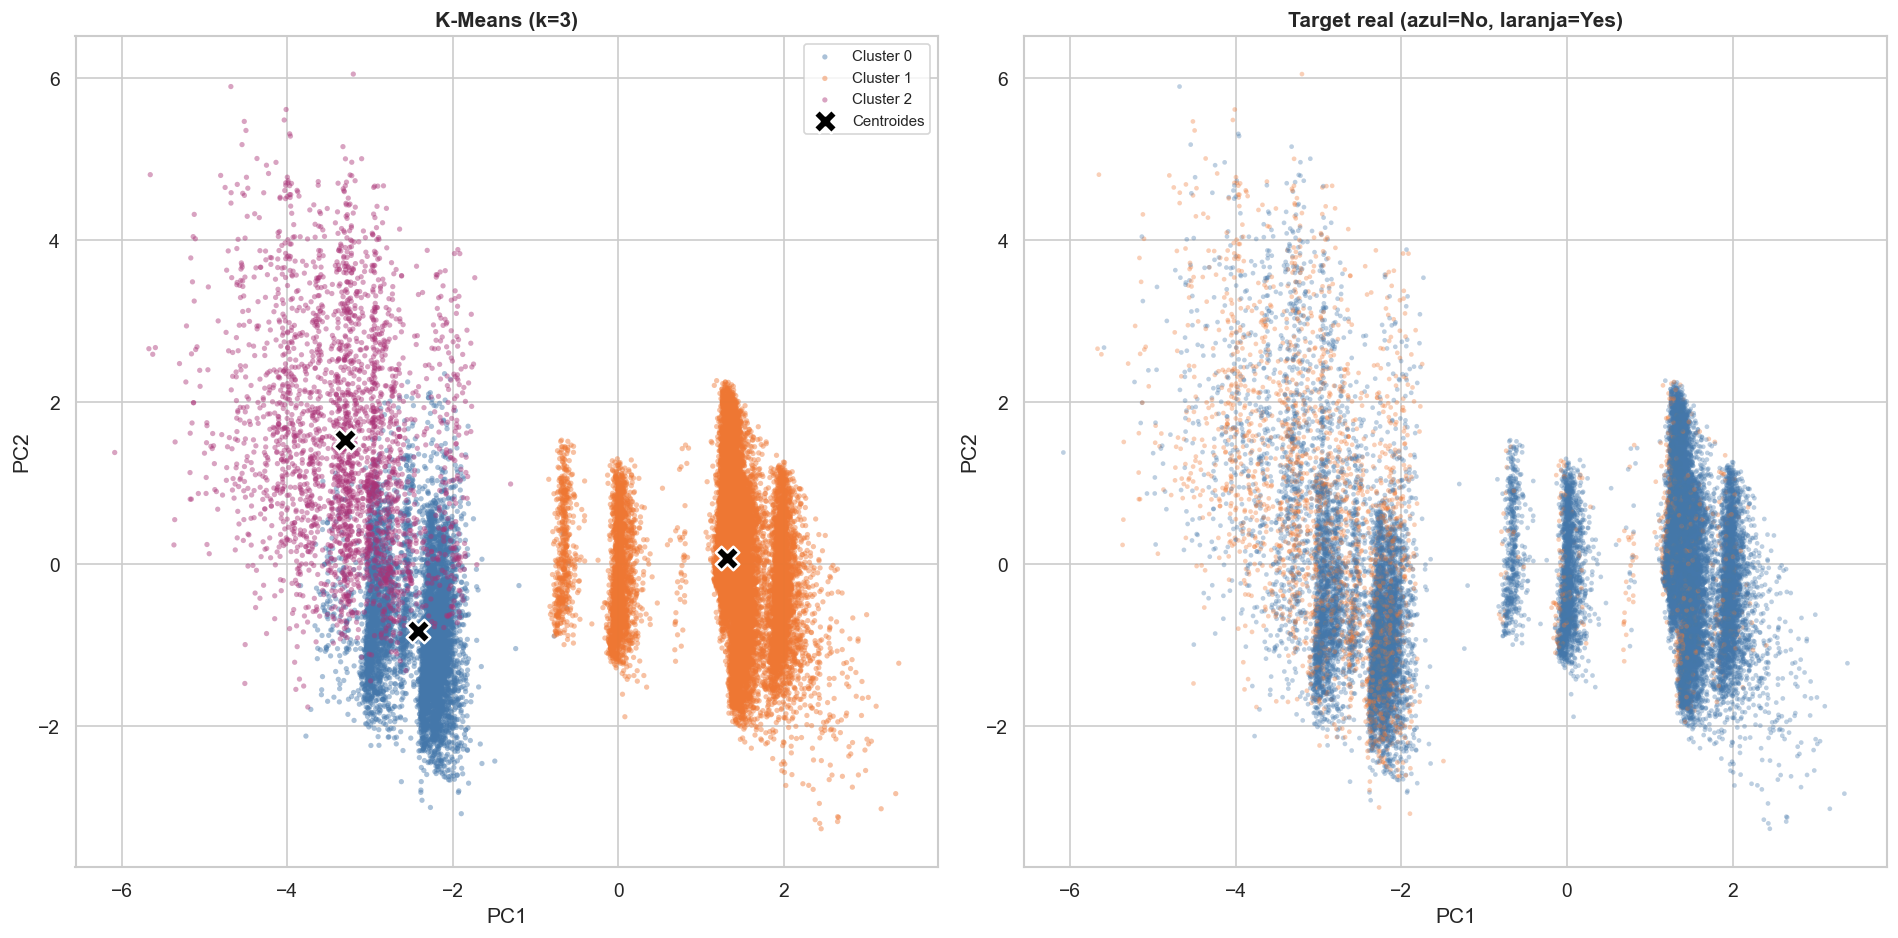

In [22]:
# paleta Tol Bright - tentativa pra deuteranopia
COLORS_3 = ["#4477AA", "#EE7733", "#AA3377"]   # azul, laranja, roxo
COLORS_2 = ["#4477AA", "#EE7733"]

def plot_clusters(X, labels, k, centers=None, title=""):
    """Plota clusters em PCA 2D com paleta acessível."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    for i in range(k):
        mask = labels == i
        colors = COLORS_3 if k >= 3 else COLORS_2
        axes[0].scatter(
            X[mask, 0], X[mask, 1],
            c=colors[i % len(colors)], alpha=0.45, s=10,
            label=f"Cluster {i}", edgecolors="none"
        )
    if centers is not None:
        axes[0].scatter(
            centers[:, 0], centers[:, 1],
            c="black", marker="X", s=200, edgecolors="white",
            linewidth=1.5, label="Centroides", zorder=5
        )
    axes[0].set_title(title, fontweight="bold")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend(fontsize=9)

    # target real: azul e laranja
    c_target = np.where(y_train == 1, "#EE7733", "#4477AA")
    axes[1].scatter(
        X[:, 0], X[:, 1],
        c=c_target, alpha=0.35, s=8, edgecolors="none"
    )
    axes[1].set_title("Target real (azul=No, laranja=Yes)",
                      fontweight="bold")
    axes[1].set_xlabel("PC1")
    axes[1].set_ylabel("PC2")

    plt.tight_layout()
    return fig

fig = plot_clusters(X_pca, km_labels, K_BEST, km_final.cluster_centers_,
                    f"K-Means (k={K_BEST})")
fig.savefig("artifacts/agrup_kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

## Conclusão K-means

> O *silhouette* indica $k = 2$ como ótimo estatístico (0.307), com $k = 3$ próximo (0.283). \
A ausência de cotovelo acentuado no *elbow* sugere que a estrutura de clusters não é fortemente \
definida - os dados não possuem agrupamentos naturais claramente separados.

> Adotamos `k = 3` por oferecer segmentação levemente mais granular para interpretação de perfis.

---

# DBSCAN

*Density-Based Spatial Clustering of Applications with Noise.*

Diferente do K-Means, o DBSCAN não exige definir $k$ \
previamente, e pode encontrar clusters de formato arbitrário.

**Conceitos-chave:**
- **Core point:** ponto com $\geq$ `min_samples` vizinhos dentro do raio $\varepsilon$
- **Border point:** dentro de $\varepsilon$ de um core point, mas sem ter `min_samples` vizinhos próprios
- **Noise (ruído):** nem core nem border - outliers

> **Parâmetros:** $\varepsilon$ (raio) e `min_samples`

Usamos o **k-distance plot** para estimar $\varepsilon$: calcula-se a \
distância ao $k$-ésimo vizinho mais próximo para cada ponto, ordena-se \
de forma decrescente e procura-se o "joelho" da curva.

> **Limitação em alta dimensão:** com 24 componentes PCA, as \
distâncias tendem a se uniformizar (maldição da dimensionalidade), \
dificultando a detecção de densidade. É esperado que o DBSCAN \
classifique muitos pontos como ruído neste cenário.

## K-distance plot

In [23]:
print(f"Número de Dimensões = {n_comp}")

Número de Dimensões = 24


Heurística para `min_samples`: a referência original do DBSCAN [(Ester et al., 1996)](https://www2.cs.sfu.ca/~ester/papers/kdd_96.pdf) sugere `min_samples >= n_dims + 1`.

Uma regra mais conservadora, encontrada em [(Sander et al., 1998)](https://doi.org/10.1023/A%3A1009745219419),  usa `2 × n_dims`. 
$\uparrow$ Com 24 componentes PCA: 2 × 24 = 48.

Para epsilon ($\varepsilon$), o método do k-distance plot procura o joelho na curva de distâncias ordenadas. O percentil 95 é uma alternativa quando não há joelho claro.

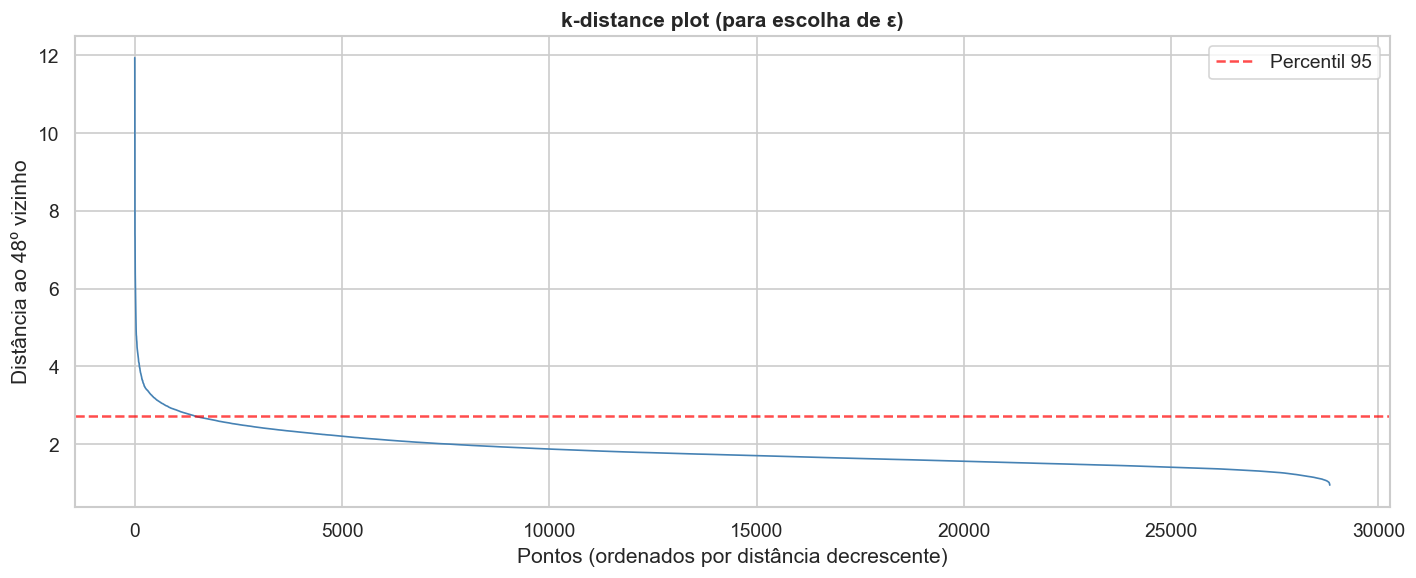

In [24]:
# heurística: 2 * nº de dimensões
MIN_SAMPLES = 2 * n_comp

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_dist, color="steelblue", linewidth=1)
ax.set_xlabel("Pontos (ordenados por distância decrescente)")
ax.set_ylabel(f"Distância ao {MIN_SAMPLES}º vizinho")
ax.set_title("k-distance plot (para escolha de ε)", fontweight="bold")
ax.axhline(y=np.percentile(k_dist, 95), color="red",
           linestyle="--", alpha=0.7, label="Percentil 95")
ax.legend()
plt.tight_layout()
fig.savefig("figures/agrup_kdist_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Sugestão de $\varepsilon$

In [25]:
print(f"Sugestão de ε (percentil 95): {np.percentile(k_dist, 95):.2f}")
print(f"Sugestão de ε (percentil 97): {np.percentile(k_dist, 97):.2f}")

Sugestão de ε (percentil 95): 2.72
Sugestão de ε (percentil 97): 2.93


## Execução e Distribuição

In [26]:
EPS = 2.72 # ajustar com base no joelho do k-distance plot (acima)

db = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
db_labels = db.fit_predict(X_pca)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()
pct_noise = n_noise / len(db_labels) * 100

print(f"DBSCAN (ε={EPS}, min_samples={MIN_SAMPLES})")
print(f"  Clusters encontrados: {n_clusters_db}")
print(f"  Pontos de ruído:      {n_noise} ({pct_noise:.1f}%)")
if n_clusters_db >= 2:
    mask = db_labels != -1
    sil_db = silhouette_score(X_pca[mask], db_labels[mask])
    print(f"  Silhouette (sem ruído): {sil_db:.4f}")

DBSCAN (ε=2.72, min_samples=48)
  Clusters encontrados: 1
  Pontos de ruído:      350 (1.2%)


In [27]:
print(f"\nDistribuição:")
print(pd.Series(db_labels).value_counts().sort_index())


Distribuição:
-1      350
 0    28479
Name: count, dtype: int64


## Visualização

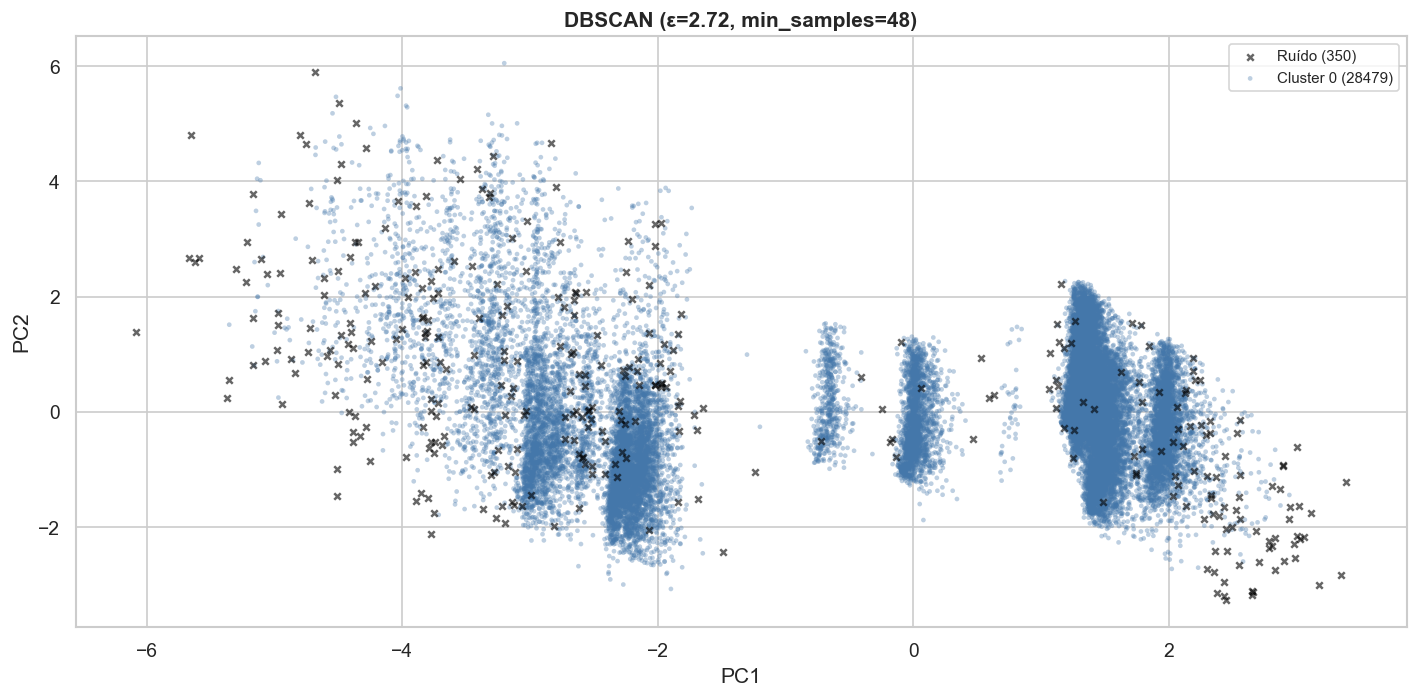

In [28]:
fig, ax = plt.subplots(figsize=(12, 6))

noise_mask = db_labels == -1

# ruído em preto com marcador diferente
ax.scatter(
    X_pca[noise_mask, 0], X_pca[noise_mask, 1],
    c="black", alpha=0.6, s=15, marker="x",
    label=f"Ruído ({n_noise})", zorder=4
)
if n_clusters_db > 0:
    ax.scatter(
        X_pca[~noise_mask, 0], X_pca[~noise_mask, 1],
        c="#4477AA", alpha=0.35, s=8, edgecolors="none",
        label=f"Cluster 0 ({(~noise_mask).sum()})"
    )

ax.set_title(
    f"DBSCAN (ε={EPS}, min_samples={MIN_SAMPLES})",
    fontweight="bold"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig("artifacts/agrup_dbscan_clusters.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Conclusão DBSCAN

> DBSCAN encontrou 1 cluster e 350 pontos de ruído (1.2%). A maldição da dimensionalidade (24 componentes) uniformiza as\
distâncias, impedindo a detecção de fronteiras de densidade. O k-distance plot sem joelho claro confirma: não há transição \
natural entre regiões densas e esparsas. Os 350 pontos de ruído são outliers genuínos - clientes com perfis atípicos.

> Esse resultado contrasta com o K-Means: abordagens baseadas em centroides (K-Means) particionam o espaço mesmo sem fronteiras \
naturais, enquanto abordagens por densidade (DBSCAN) reportam honestamente a ausência de estrutura.

---

# Agrupamento Hierárquico

O agrupamento aglomerativo (bottom-up) começa com cada ponto como seu próprio cluster e vai fundindo \
os pares mais próximos iterativamente. O **dendrograma** visualiza essa hierarquia de fusões, permitindo \
escolher o número de clusters pelo ponto de corte.

**Linkage (critério de fusão):**
- *Ward:* minimiza o aumento da variância intra-cluster ao fundir - produz clusters de tamanho similar (análogo ao K-Means)
- *Complete:* distância máxima entre pontos dos dois clusters
- *Average:* distância média entre todos os pares

> Usamos **Ward** por ser o mais robusto para dados de alta dimensão e produzir resultados comparáveis ao K-Means.

## Dendograma

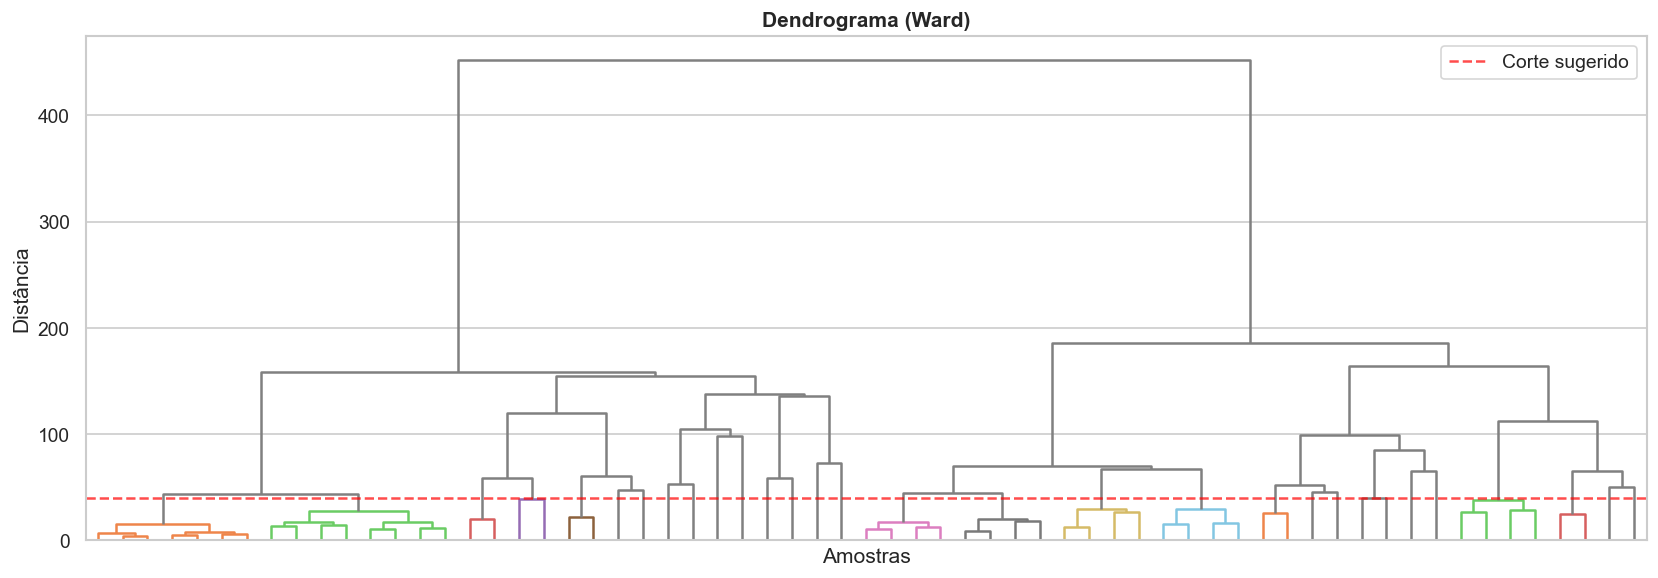

In [30]:
Z = linkage(X_pca, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, truncate_mode="level", p=5,
    color_threshold=40, ax=ax,
    above_threshold_color="gray",
    no_labels=True
)
ax.set_title("Dendrograma (Ward)", fontweight="bold")
ax.set_xlabel("Amostras")
ax.set_ylabel("Distância")
ax.axhline(y=40, color="red", linestyle="--", alpha=0.7,
           label="Corte sugerido")
ax.legend()
plt.tight_layout()
fig.savefig("figures/agrup_dendrograma.png", dpi=150, bbox_inches="tight")
plt.show()

> O dendrograma confirma o que silhouette e elbow mostraram: a primeira divisão (2 grupos) é clara, \
a segunda (3 grupos) é razoável, e depois disso a estrutura se fragmenta. Não tem muito o que fazer.

## Aglomerativo

In [33]:
K_HIER = 3  # ajustado com base no dendrograma

agg = AgglomerativeClustering(n_clusters=K_HIER, linkage="ward")
agg_labels = agg.fit_predict(X_pca)

sil_agg = silhouette_score(X_pca, agg.fit_predict(X_pca))
ch_agg  = calinski_harabasz_score(X_pca, agg_labels)
db_agg  = davies_bouldin_score(X_pca, agg_labels)

print(f"Hierárquico Ward (k={K_HIER})")
print(f"  Silhouette:        {sil_agg:.4f}")
print(f"  Calinski-Harabasz: {ch_agg:.1f}")
print(f"  Davies-Bouldin:    {db_agg:.4f}")
print(f"\nDistribuição:")
print(pd.Series(agg_labels).value_counts().sort_index())

Hierárquico Ward (k=3)
  Silhouette:        0.2972
  Calinski-Harabasz: 7071.1
  Davies-Bouldin:    1.5313

Distribuição:
0     7944
1    19360
2     1525
Name: count, dtype: int64


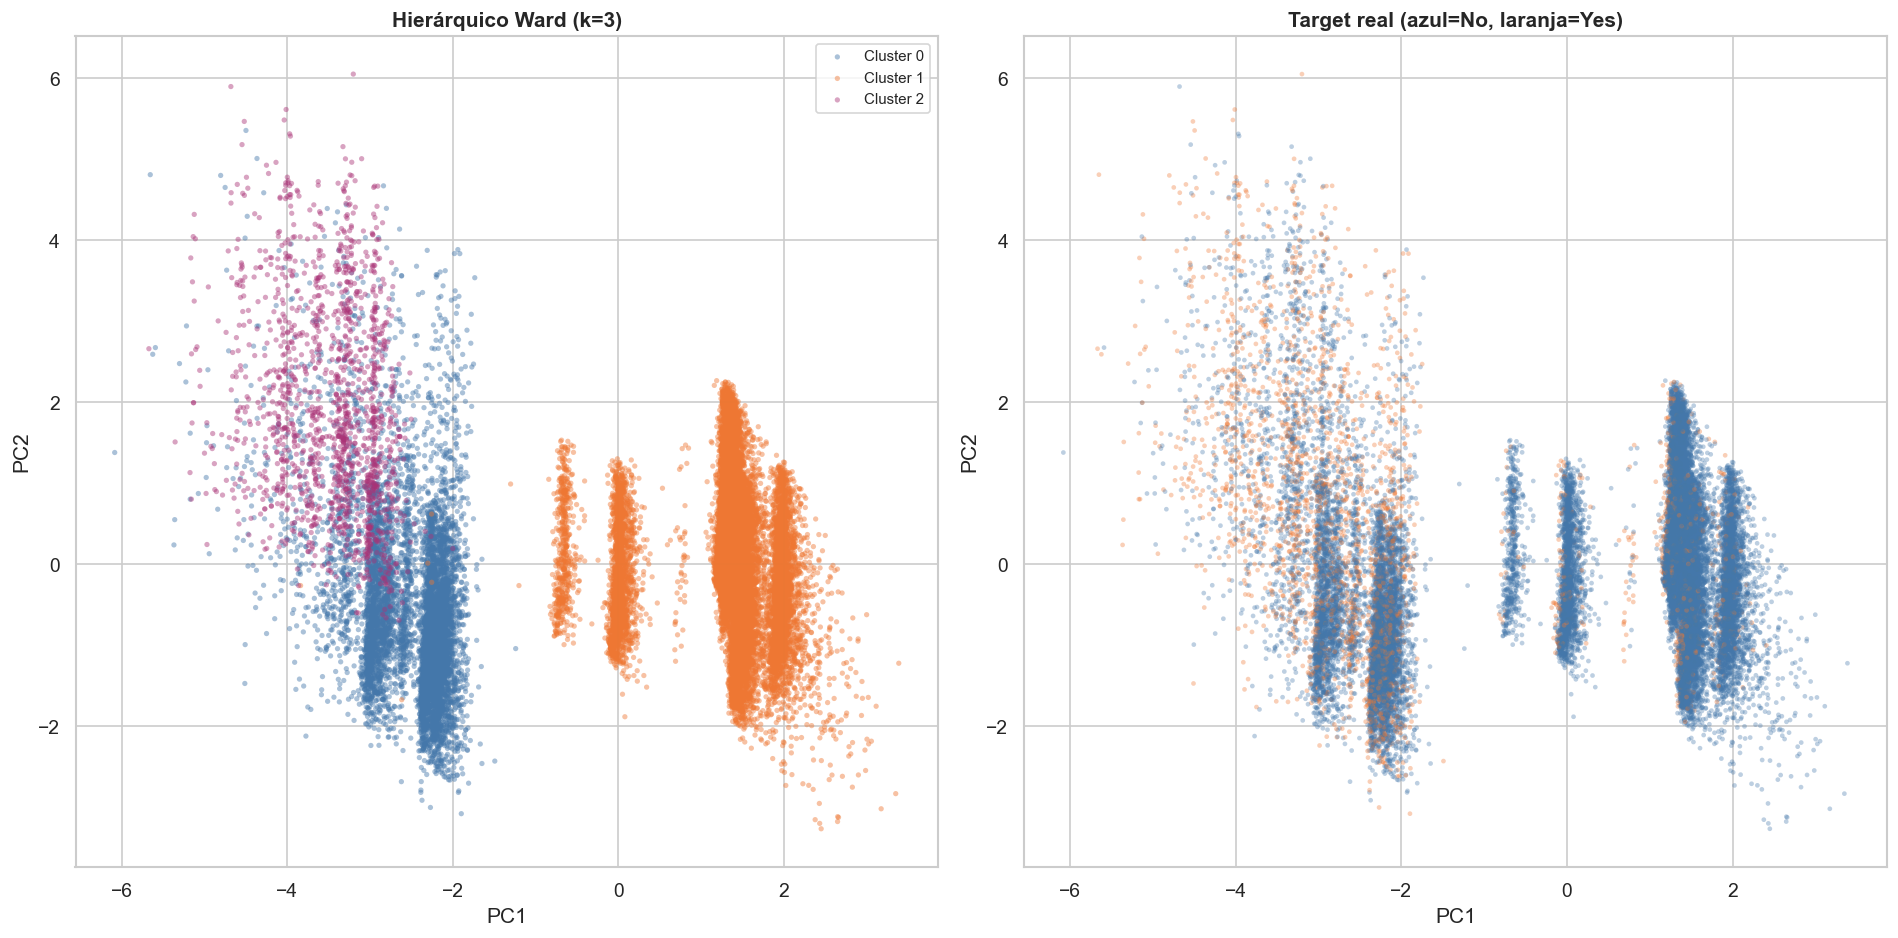

In [34]:
fig = plot_clusters(X_pca, agg_labels, K_HIER,
                    title=f"Hierárquico Ward (k={K_HIER})")
fig.savefig("figures/agrup_hierarquico.png", dpi=150, bbox_inches="tight")
plt.show()

---

# _Gaussian Mixture Model_ (GMM)

O GMM modela os dados como uma mistura de $k$ distribuições gaussianas multivariadas. \
Diferente do K-Means (hard assignment), o GMM atribui a cada ponto uma **probabilidade** \
de pertencer a cada cluster (soft assignment):

$$p(x) = \sum_{k=1}^{K} \pi_k \;\mathcal{N}(x \mid \mu_k, \Sigma_k)$$

onde $\pi_k$ são os pesos (mixing coefficients), e cada componente tem sua própria média $\mu_k$ e covariância $\Sigma_k$. \
Aqui, os parâmetros são estimados pelo algoritmo EM (Expectation-Maximization).

**Vantagens sobre K-Means:**
- Clusters podem ter formato elíptico (não apenas esférico)
- Soft assignment: pontos na fronteira recebem probabilidades divididas entre clusters vizinhos
- Permite usar **BIC/AIC** para seleção de modelo (escolha de $k$)

## Testando diferentes K

In [35]:
K_gmm_range = range(2, 8)
bic_scores = []
aic_scores = []

for k in K_gmm_range:
    gmm = GaussianMixture(
        n_components=k, covariance_type="full",
        random_state=SEED, n_init=3
    )
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))
    print(f"k={k} | BIC: {gmm.bic(X_pca):>12.1f} | "
          f"AIC: {gmm.aic(X_pca):>12.1f}")

k=2 | BIC:     691920.6 | AIC:     686554.0
k=3 | BIC:     210757.3 | AIC:     202703.1
k=4 | BIC:      -2071.6 | AIC:     -12813.2
k=5 | BIC:    -224818.2 | AIC:    -238247.3
k=6 | BIC:    -312743.8 | AIC:    -328860.3
k=7 | BIC:    -400937.2 | AIC:    -419741.2


## Seleção do GMM por BIC e AIC

AIC (*Akaike Information Criterion*) e BIC (*Bayesian Information Criterion*) \
balanceiam **qualidade do ajuste** contra **complexidade do modelo**:

$$\text{AIC} = -2 \ln(L) + 2p$$

$$\text{BIC} = -2 \ln(L) + p \ln(n)$$

onde $L$ é a verossimilhança maximizada, $p$ o número \
de parâmetros e $n$ o número de amostras. **Menor = melhor.**

O BIC penaliza complexidade mais fortemente que o AIC \
($\ln(n) > 2$ para $n > 7$), favorecendo modelos mais simples.

> Nos resultados, ambos decrescem monotonicamente até $k = 7$ sem atingir mínimo, \
indicando que o GMM continua encontrando estrutura com mais componentes. \
Consistente com a ausência de um número "natural" de clusters nesse dataset.

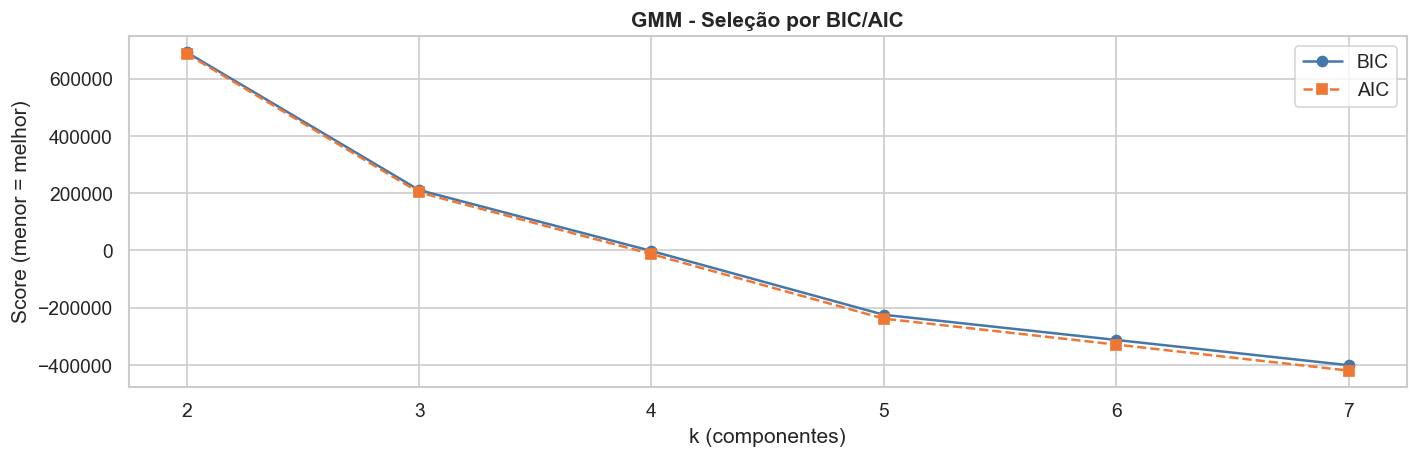

In [36]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(K_gmm_range, bic_scores, "o-", label="BIC", color="#4477AA")
ax.plot(K_gmm_range, aic_scores, "s--", label="AIC", color="#EE7733")
ax.set_xlabel("k (componentes)")
ax.set_ylabel("Score (menor = melhor)")
ax.set_title("GMM - Seleção por BIC/AIC", fontweight="bold")
ax.set_xticks(list(K_gmm_range))
ax.legend()
plt.tight_layout()
fig.savefig("figures/agrup_gmm_bic.png", dpi=150, bbox_inches="tight")
plt.show()

## GMM Escolhido

In [39]:
K_GMM = 7 # ajustado pelo mínimo do BIC

gmm_final = GaussianMixture(
    n_components=K_GMM, covariance_type="full",
    random_state=SEED, n_init=5
)
gmm_labels = gmm_final.fit_predict(X_pca)
gmm_probs  = gmm_final.predict_proba(X_pca)

sil_gmm = silhouette_score(X_pca, gmm_final.predict(X_pca))
ch_gmm  = calinski_harabasz_score(X_pca, gmm_labels)
db_gmm  = davies_bouldin_score(X_pca, gmm_labels)

print(f"GMM (k={K_GMM})")
print(f"  Silhouette:        {sil_gmm:.4f}")
print(f"  Calinski-Harabasz: {ch_gmm:.1f}")
print(f"  Davies-Bouldin:    {db_gmm:.4f}")
print(f"\nDistribuição:")
print(pd.Series(gmm_labels).value_counts().sort_index())

GMM (k=7)
  Silhouette:        0.1414
  Calinski-Harabasz: 3919.1
  Davies-Bouldin:    2.1666

Distribuição:
0    3619
1    4369
2    7767
3    5383
4    2662
5    2499
6    2530
Name: count, dtype: int64


In [40]:
# certeza do GMM: max probabilidade por ponto
max_prob = gmm_probs.max(axis=1)
print(f"\nCerteza média: {max_prob.mean():.2%}")
print(f"Pontos com certeza < 70%: "
      f"{(max_prob < 0.7).sum()} ({(max_prob < 0.7).mean():.1%})")


Certeza média: 99.99%
Pontos com certeza < 70%: 1 (0.0%)


## Soft assignment do GMM

Diferente do K-Means (cada ponto pertence a exatamente 1 cluster), o GMM atribui\
probabilidades: $P(\text{cluster}_k \mid x)$ para cada componente $k$.

A **certeza** é $\max_k P(\text{cluster}_k \mid x)$: se um ponto tem certeza 95%, \
ele pertence ao cluster dominante com 95% de probabilidade e distribui os 5% restantes \
entre os demais. Certeza próxima de 100% indica que os componentes gaussianos são \
bem separados no espaço 24D do PCA, enquanto pontos nas fronteiras teriam certeza menor.

> No nosso caso, certeza média de 99.99% com apenas 1 ponto abaixo de 70% indica \
**separação quase perfeita entre os componentes** - o GMM está muito confiante, porém \
a métrica **silhouette baixa (0.14)** revela que essa **separação não se traduz em clusters compactos** \
e bem isolados pela distância euclidiana.

## Visualização

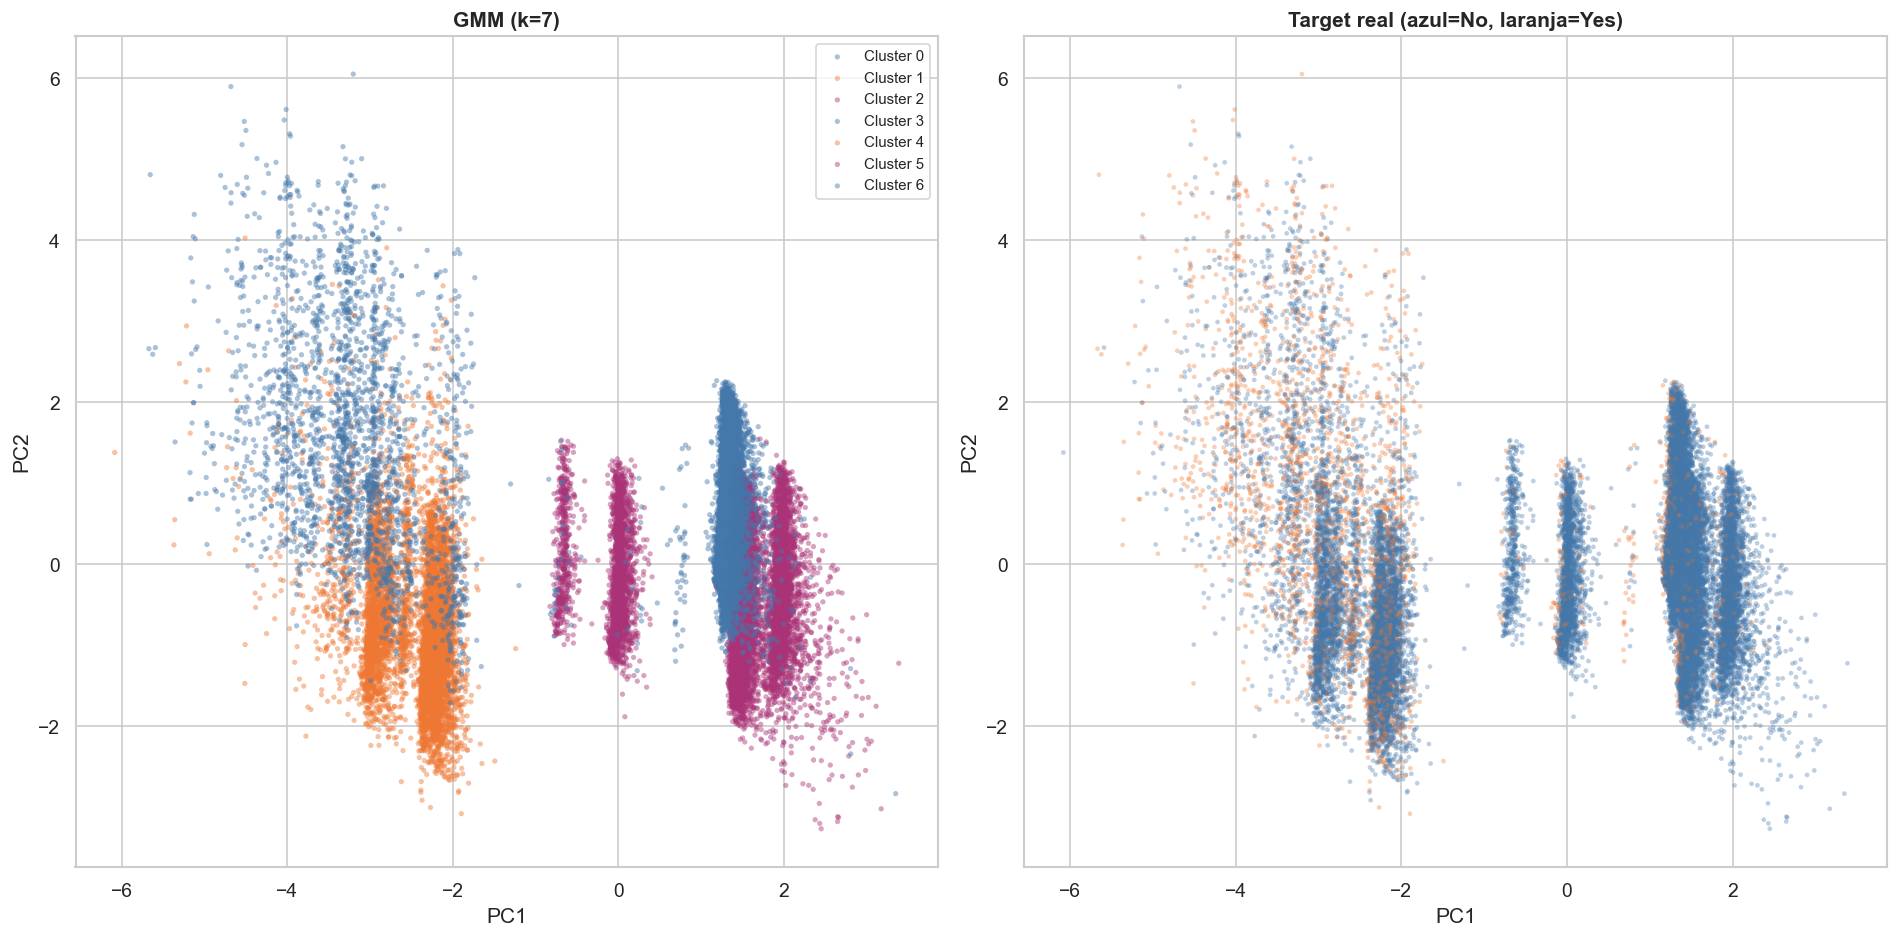

In [41]:
fig = plot_clusters(X_pca, gmm_labels, K_GMM,
                    title=f"GMM (k={K_GMM})")
fig.savefig("figures/agrup_gmm_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

---

# Comparação

## Tabela Comparativa das Métricas

In [49]:
comp_df = pd.DataFrame({
    "Silhouette":       [0.3074, 0.2833, 0.2972, 0.1414],
    "Calinski-Harabasz": [11310.3, 7392.1, 7071.1, 3919.1],
    "Davies-Bouldin":   [1.4651, 1.7024, 1.5313, 2.1666],
}, index=["K-Means (k=2)", "K-Means (k=3)", "Ward (k=3)", "GMM (k=7)"]).sort_values("Silhouette", ascending=True)

,Silhouette,Calinski-Harabasz,Davies-Bouldin
GMM (k=7),0.1414,3919.1000,2.1666
K-Means (k=3),0.2833,7392.1000,1.7024
Ward (k=3),0.2972,7071.1000,1.5313
K-Means (k=2),0.3074,11310.3000,1.4651


> Relembrando: Silhouette é melhor maior (0.25 - 0.50 é razoável), \
Calinski-Harabasz é melhor maior  e Davies-Bouldin é melhor menor

---

## Visualização do Comparativo

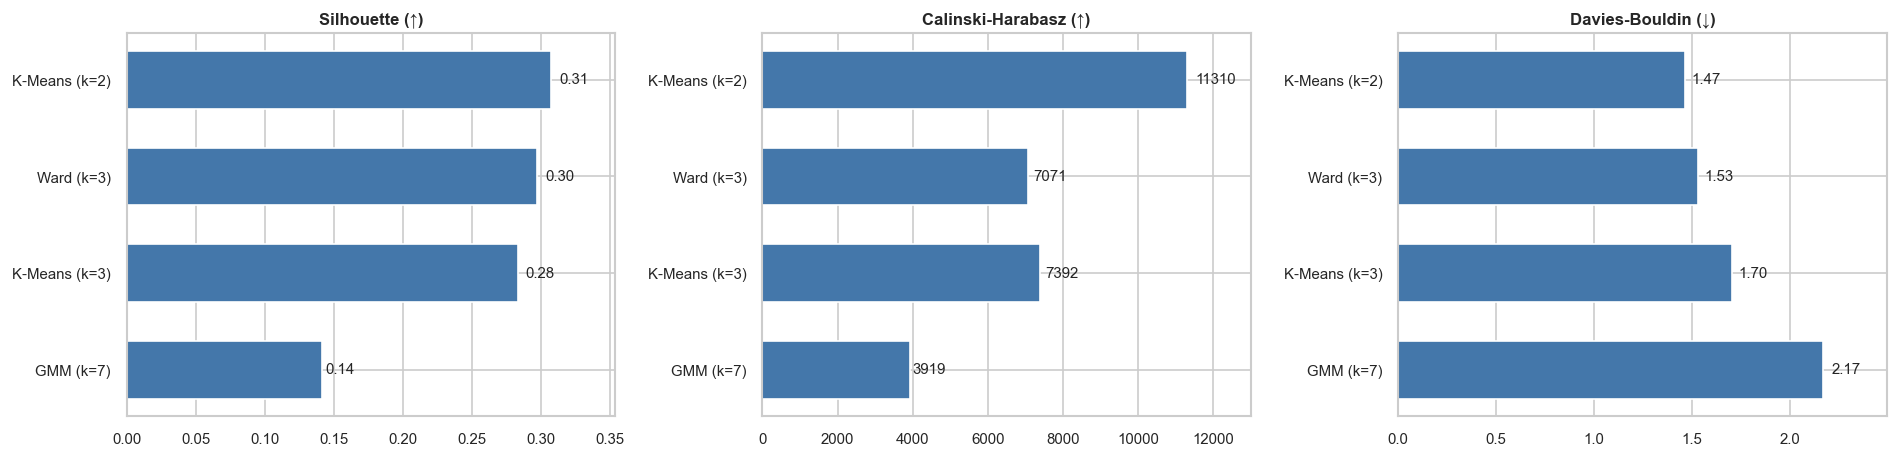

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ["Silhouette (↑)", "Calinski-Harabasz (↑)", "Davies-Bouldin (↓)"]
colors = ["#4477AA", "#4477AA", "#4477AA"]

for ax, col, title in zip(axes, comp_df.columns, titles):
    bars = ax.barh(comp_df.index, comp_df[col],
                   color="#4477AA", edgecolor="white", height=0.6)
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.tick_params(labelsize=9)
    for bar, v in zip(bars, comp_df[col]):
        label = f"{v:.2f}" if v < 100 else f"{v:.0f}"
        ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
                label, va="center", fontsize=9)
    ax.set_xlim(0, comp_df[col].max() * 1.15)

plt.tight_layout()
fig.savefig("artifacts/agrup_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()

> K-Means com $k = 2$ domina as três métricas (silhouette 0.31, CH 11310, DB 1.47), confirmando que \
a partição binária é a mais natural estatisticamente

>Ward $(k = 3)$ supera ligeiramente K-Means $(k = 3)$ em silhouette (0.30 vs 0.28) e DB (1.53 vs 1.70), \
sugerindo que o critério hierárquico produz clusters marginalmente mais compactos

> GMM $(k = 7)$ apresenta as piores métricas (silhouette 0.14), indicando que 7 componentes \
fragmentam a estrutura além do suportado pelos dados.

> DBSCAN (1 cluster, não incluído por ausência de métricas válidas) reforça que não há fronteiras de densidade

---

# Salvando os Artefatos

In [54]:
comp_df.to_csv("artifacts/df_agrup_comparativo.csv")
joblib.dump(km_final, "artifacts/model_kmeans.joblib")
joblib.dump(gmm_final, "artifacts/model_gmm.joblib")
print("Artefatos de agrupamento salvos.")

Artefatos de agrupamento salvos.


---

# Conclusão

## Comparação dos métodos

| Método | Resultado | Interpretação |
|---|---|---|
| K-Means (k=2) | Silhouette 0.31 | Melhor separação estatística; partição binária ao longo de PC1 |
| K-Means (k=3) | Silhouette 0.28 | Segmentação mais granular; subdivide o grupo menor |
| Hierárquico Ward (k=3) | Silhouette 0.30 | Convergente com K-Means - confirma robustez da estrutura |
| DBSCAN | 1 cluster + 1.2% ruído | Sem fronteiras de densidade; dados formam região contínua |
| GMM (k=7) | Silhouette 0.14, certeza 99.9% | Granularidade máxima; confiante mas clusters menos compactos |

## Achados principais

1. **Estrutura moderada, não forte.** Silhouette máximo de 0.31 (faixa "razoável") indica que \
os dados não possuem clusters naturais claramente separados - a segmentação é uma partição \
imposta pelo algoritmo, não uma fronteira natural proveniente por estrutura dos próprios dados

2. **Convergência entre métodos.** K-Means e Hierárquico Ward produzem partições quase idênticas, \
confirmando que a estrutura encontrada é robusta e não artefato algorítmico

3. **DBSCAN como contraste.** A abordagem por densidade não encontra clusters, reforçando que a estrutura é de \
*gradiente contínuo* (não há "vales" de baixa densidade entre grupos), apenas regiões de concentração relativa

4. **GMM revela granularidade adicional.** BIC/AIC decrescem monotonicamente, sugerindo que o GMM pode continuar \
subdividindo - o dataset tem sub-estrutura interna que pode sugerir caminhos de investigação em trabalhos futuros

5. **Conexão com a classificação:** o eixo principal de variação (PC1) é dominado pelas features socioeconômicas, \
que também lideraram a importância na classificação. Os clusters capturam *períodos macroeconômicos distintos* \
ao invés de classes individuais de clientes, que seria nosso objetivo ideal aqui

## Recomendação

> Para segmentação prática, **K-Means com $k = 3$** é a escolha mais racional: balanceia qualidade estatística \
(silhouette 0.28, próximo do ótimo 0.31 com $k = 2$) com interpretabilidade (3 segmentos relativamente "perfiláveis").

> A ausência de clusters "naturais" fortes sugere que estratégias de marketing baseadas em regras \
(árvore de decisão da classificação) podem ser mais eficazes que segmentação por agrupamento para este dataset.

---

# Fim